## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../../Mamoth Modules")
sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)


In [4]:
dataset

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213
1,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432
2,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009
3,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316
4,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-27,27,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,14240.000000,13997.000000,14065.322581,14193.357143,14176.225806,14176.225806,13751.806452,13779.178571,13721.193548,13721.193548,0.000000
3067204,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14240.000000,13997.000000,14065.322581,14193.357143,14176.225806,14176.225806,13751.806452,13779.178571,13721.193548,13721.193548,0.000000
3067205,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-29,29,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,14240.000000,13914.000000,14065.322581,14193.357143,14176.225806,14176.225806,13751.806452,13779.178571,13721.193548,13721.193548,0.000000
3067206,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-30,30,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,14240.000000,13923.000000,14065.322581,14193.357143,14176.225806,14176.225806,13751.806452,13779.178571,13721.193548,13721.193548,0.000000


In [5]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [6]:
dataset.shape

(3067208, 31)

In [7]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [8]:
dataset2 = pd.DataFrame()
groups = dataset.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset2 = dataset2.append(temp_df)

dataset2.reset_index(drop=True, inplace=True)

In [9]:
dataset2

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,πελλας,κεντρικης μακεδονιας,21.784110,40.821750,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,3.768066,3.768066,3.768066,3.768066
1,πελλας,κεντρικης μακεδονιας,21.784110,40.821750,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,2.864009,6.632075,6.632075,6.632075
2,πελλας,κεντρικης μακεδονιας,21.784110,40.821750,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13776.000000,NaN,NaN,NaN,1.146590,7.778665,7.778665,7.778665
3,πελλας,κεντρικης μακεδονιας,21.784110,40.821750,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13717.500000,NaN,NaN,NaN,0.413468,8.192133,8.192133,8.192133
4,πελλας,κεντρικης μακεδονιας,21.784110,40.821750,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13682.400000,NaN,NaN,NaN,2.318093,10.510226,10.510226,10.510226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,σερρων,κεντρικης μακεδονιας,24.069540,40.979960,2022-12-27,27,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14157.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,0.000000,0.756312,1446.142168
3067204,σερρων,κεντρικης μακεδονιας,24.069540,40.979960,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14043.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,0.000000,0.090257,1446.142168
3067205,σερρων,κεντρικης μακεδονιας,24.069540,40.979960,2022-12-29,29,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14154.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,0.000000,0.090257,1446.142168
3067206,σερρων,κεντρικης μακεδονιας,24.069540,40.979960,2022-12-30,30,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14110.000000,13907.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,0.000000,0.000000,1446.142168


In [46]:
grouped = dataset2.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14262.127273,NaN,NaN,NaN,14005.407407,NaN,NaN,NaN,1.216681,1.216681,1.216681,1.216681
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14350.503937,NaN,NaN,NaN,14039.913386,NaN,NaN,NaN,0.020066,0.020066,0.020066,0.020066
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14266.670330,NaN,NaN,NaN,14021.142857,NaN,NaN,NaN,0.000223,0.000223,0.000223,0.000223
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14220.556818,NaN,NaN,NaN,13991.261364,NaN,NaN,NaN,0.406945,0.406945,0.406945,0.406945
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14455.555556,NaN,NaN,NaN,14110.933333,NaN,NaN,NaN,1.073789,1.073789,1.073789,1.073789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.087912,13814.912088,14066.867167,14351.524725,14398.353421,14398.353421,13633.095356,13714.459576,13666.662177,13666.662177,0.000000,0.010527,0.018527,1077.473491
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,14220.125000,13826.840909,14059.543512,14303.178977,14298.990836,14298.990836,13628.980230,13709.562500,13664.076979,13664.076979,0.000000,0.428337,0.651870,1158.041206
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,14247.533333,13901.000000,14102.108244,14304.360317,14292.009319,14292.009319,13680.272975,13767.332540,13717.169176,13717.169176,0.000000,1.072827,3.092039,1224.182744
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31.000000,12.000000,2022.000000,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,14215.175325,13808.636364,13999.296165,14300.688312,14376.047759,14376.047759,13638.179305,13735.676716,13690.758483,13690.758483,0.000000,-0.000000,0.134849,1089.631358


In [47]:
dataset.shape

(33236, 34)

In [48]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [49]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14262.127273,NaN,NaN,NaN,14005.407407,NaN,NaN,NaN,1.216681,1.216681,1.216681,1.216681
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14350.503937,NaN,NaN,NaN,14039.913386,NaN,NaN,NaN,0.020066,0.020066,0.020066,0.020066
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14266.670330,NaN,NaN,NaN,14021.142857,NaN,NaN,NaN,0.000223,0.000223,0.000223,0.000223
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14220.556818,NaN,NaN,NaN,13991.261364,NaN,NaN,NaN,0.406945,0.406945,0.406945,0.406945
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14455.555556,NaN,NaN,NaN,14110.933333,NaN,NaN,NaN,1.073789,1.073789,1.073789,1.073789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.087912,13814.912088,14066.867167,14351.524725,14398.353421,14398.353421,13633.095356,13714.459576,13666.662177,13666.662177,0.000000,0.010527,0.018527,1077.473491
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,14220.125000,13826.840909,14059.543512,14303.178977,14298.990836,14298.990836,13628.980230,13709.562500,13664.076979,13664.076979,0.000000,0.428337,0.651870,1158.041206
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,14247.533333,13901.000000,14102.108244,14304.360317,14292.009319,14292.009319,13680.272975,13767.332540,13717.169176,13717.169176,0.000000,1.072827,3.092039,1224.182744
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31.000000,12.000000,2022.000000,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,14215.175325,13808.636364,13999.296165,14300.688312,14376.047759,14376.047759,13638.179305,13735.676716,13690.758483,13690.758483,0.000000,-0.000000,0.134849,1089.631358


In [50]:
# dataset['lst_jan_mean'] = (dataset['lst_day_jan_mean'] + dataset['lst_night_jan_mean'])/2
# dataset['lst_feb_mean'] = (dataset['lst_day_feb_mean'] + dataset['lst_night_feb_mean'])/2
# dataset['lst_mar_mean'] = (dataset['lst_day_mar_mean'] + dataset['lst_night_mar_mean'])/2
# dataset['lst_apr_mean'] = (dataset['lst_day_apr_mean'] + dataset['lst_night_apr_mean'])/2

In [51]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [52]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [53]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14262.127273,NaN,NaN,NaN,14005.407407,NaN,NaN,NaN,1.216681,1.216681,1.216681,1.216681,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14350.503937,NaN,NaN,NaN,14039.913386,NaN,NaN,NaN,0.020066,0.020066,0.020066,0.020066,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14266.670330,NaN,NaN,NaN,14021.142857,NaN,NaN,NaN,0.000223,0.000223,0.000223,0.000223,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14220.556818,NaN,NaN,NaN,13991.261364,NaN,NaN,NaN,0.406945,0.406945,0.406945,0.406945,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14455.555556,NaN,NaN,NaN,14110.933333,NaN,NaN,NaN,1.073789,1.073789,1.073789,1.073789,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.087912,13814.912088,14066.867167,14351.524725,14398.353421,14398.353421,13633.095356,13714.459576,13666.662177,13666.662177,0.000000,0.010527,0.018527,1077.473491,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31,12,2022,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,14220.125000,13826.840909,14059.543512,14303.178977,14298.990836,14298.990836,13628.980230,13709.562500,13664.076979,13664.076979,0.000000,0.428337,0.651870,1158.041206,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31,12,2022,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,14247.533333,13901.000000,14102.108244,14304.360317,14292.009319,14292.009319,13680.272975,13767.332540,13717.169176,13717.169176,0.000000,1.072827,3.092039,1224.182744,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31,12,2022,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,14215.175325,13808.636364,13999.296165,14300.688312,14376.047759,14376.047759,13638.179305,13735.676716,13690.758483,13690.758483,0.000000,-0.000000,0.134849,1089.631358,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [54]:
dataset.reset_index(drop=True, inplace=True)

<AxesSubplot:>

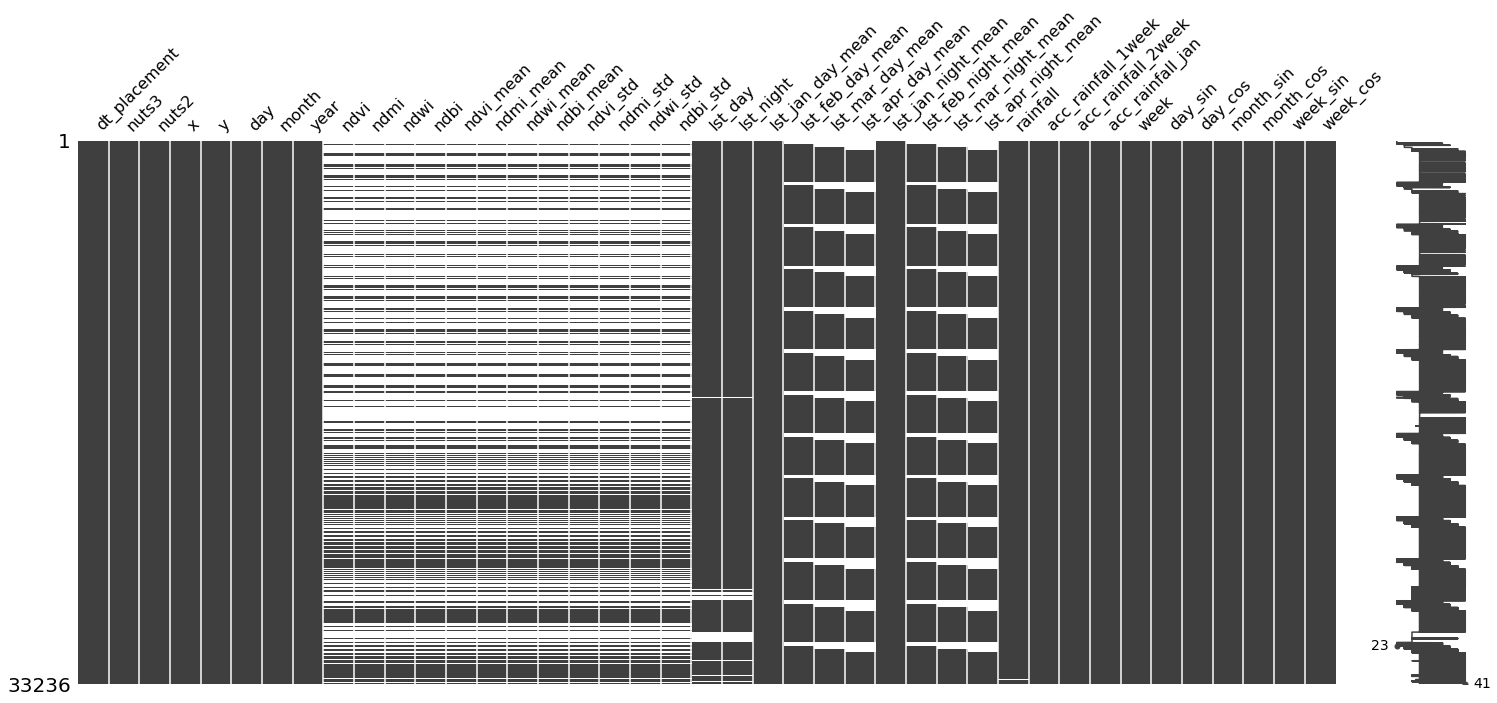

In [55]:
missingno.matrix(dataset)

In [56]:
print(dataset.columns)

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'day', 'month', 'year',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean',
       'lst_apr_day_mean', 'lst_jan_night_mean', 'lst_feb_night_mean',
       'lst_mar_night_mean', 'lst_apr_night_mean', 'rainfall',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 'week',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos'],
      dtype='object')


In [57]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [58]:
mosquito_data.nuts2.unique()

array(['κεντρικης μακεδονιας', 'θεσσαλιας', 'κρητης', 'δυτικης ελλαδας'],
      dtype=object)

In [59]:
mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [60]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [61]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


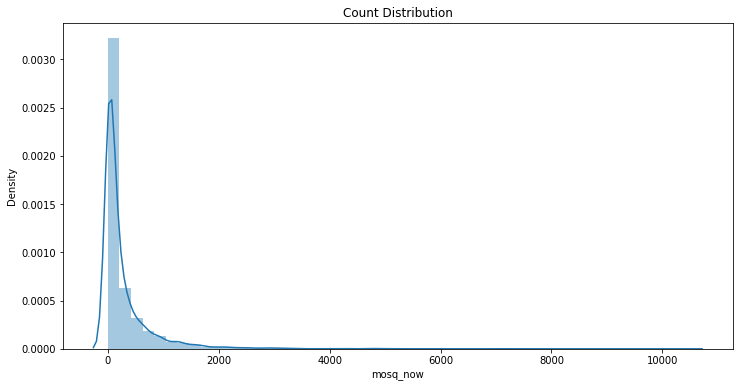

In [62]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [63]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_11512/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


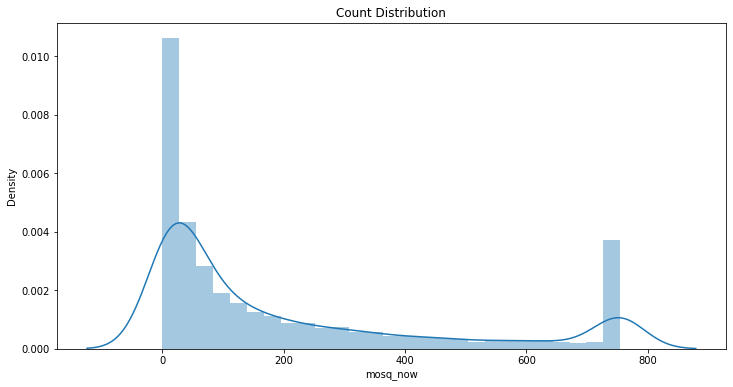

In [64]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

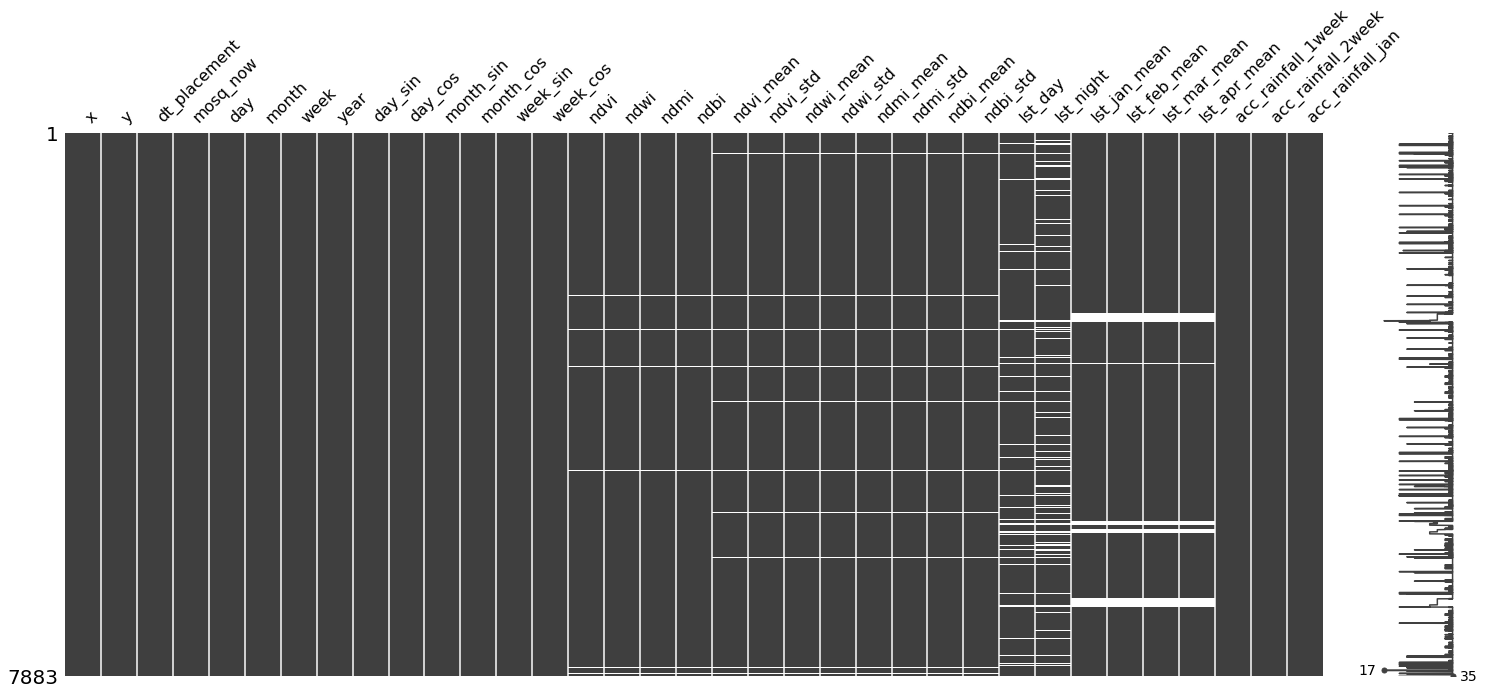

In [65]:
missingno.matrix(mosquito_data_nuts2)

In [66]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

# features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                         'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
#                         'lst_day', 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [67]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

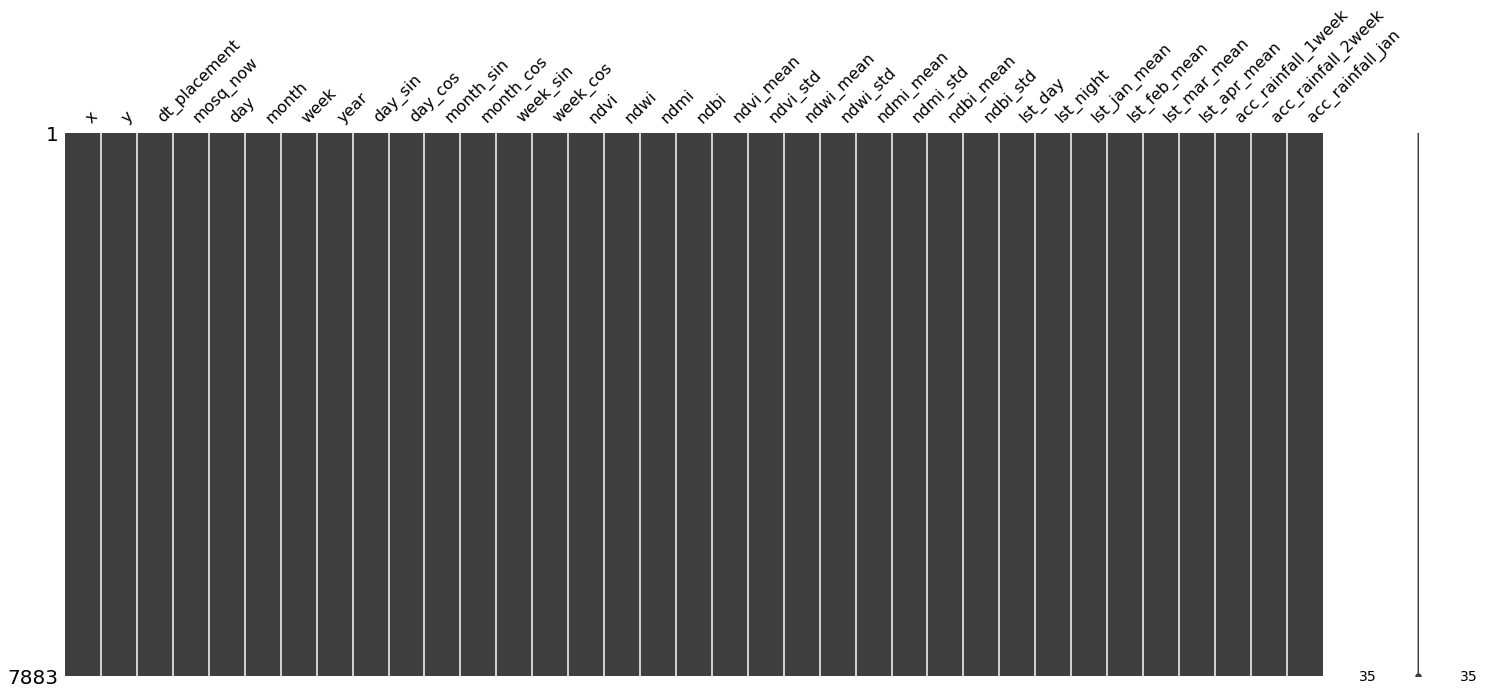

In [68]:
missingno.matrix(mosquito_data_nuts2)

In [69]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [70]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [71]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.35141 | Val Loss: 23.94051 | Train Acc: 2.608| Val Acc: 2.014
Epoch 002: | Train Loss: 18.66614 | Val Loss: 25.47832 | Train Acc: 2.257| Val Acc: 2.030
Epoch 003: | Train Loss: 18.19910 | Val Loss: 25.92373 | Train Acc: 2.177| Val Acc: 2.098
Epoch 004: | Train Loss: 17.85706 | Val Loss: 25.34516 | Train Acc: 2.112| Val Acc: 2.029
Epoch 005: | Train Loss: 17.74199 | Val Loss: 23.89795 | Train Acc: 2.107| Val Acc: 1.942
Epoch 006: | Train Loss: 17.55777 | Val Loss: 23.94322 | Train Acc: 2.061| Val Acc: 1.920
Epoch 007: | Train Loss: 17.23588 | Val Loss: 24.01726 | Train Acc: 2.045| Val Acc: 1.982
Epoch 008: | Train Loss: 17.09621 | Val Loss: 24.27375 | Train Acc: 2.027| Val Acc: 1.968
Epoch 009: | Train Loss: 16.87276 | Val Loss: 24.11941 | Train Acc: 2.006| Val Acc: 1.976
Epoch 010: | Train Loss: 16.87145 | Val Loss: 23.97033 | Train Acc: 2.012| Val Acc: 1.979
Epoch 011: | Train Loss: 16.58861 | Val Loss: 24.00449 | Train Acc: 1.981| Val Acc: 2.003
Epoch 012:

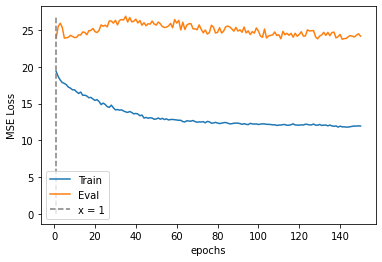

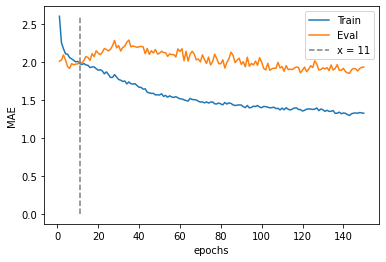

In [72]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [73]:
metrics(train, test, threshold=30)

MAE on train set:  147.3626315186127
min prediction: 1
max prediction: 1140

MAE on test set:  151.56558983950072
Error ⩽ 30: 20.98 %
min prediction: 1
max prediction: 1176


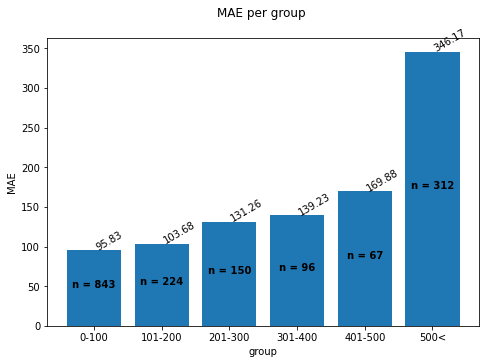

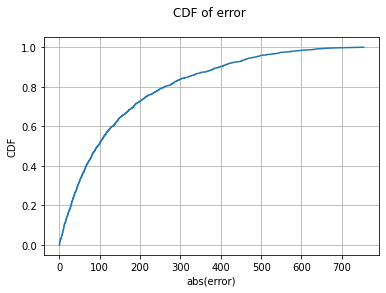

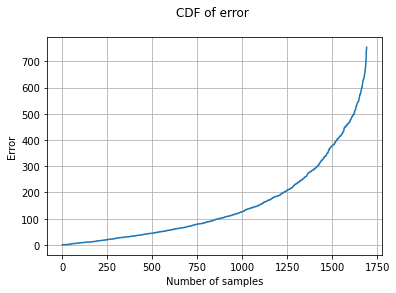

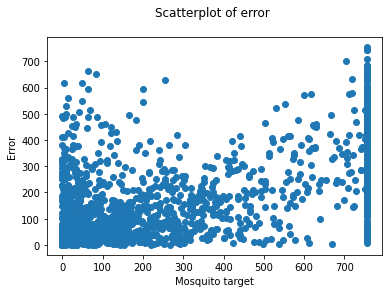

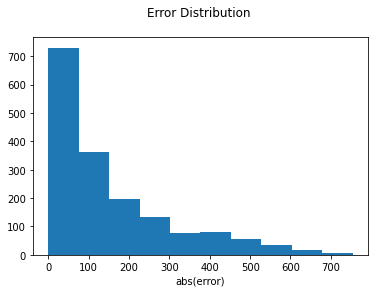

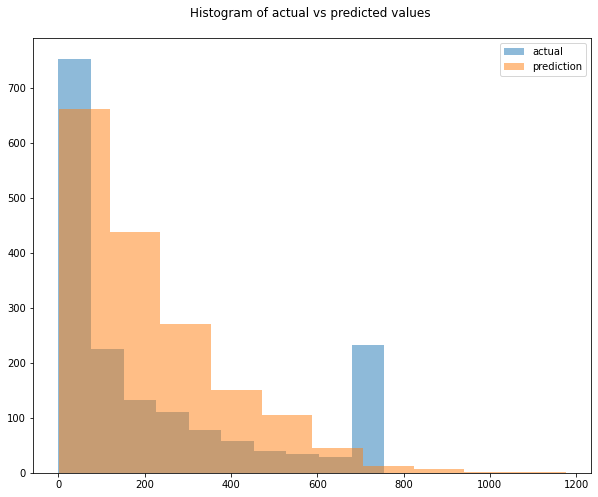

In [74]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.48700 | Val Loss: 0.26066 | Train Acc: 1.559| Val Acc: 0.633
Epoch 002: | Train Loss: 13.58997 | Val Loss: 1.17781 | Train Acc: 1.583| Val Acc: 0.633
Epoch 003: | Train Loss: 13.44699 | Val Loss: 0.38998 | Train Acc: 1.543| Val Acc: 0.633
Epoch 004: | Train Loss: 13.32724 | Val Loss: 0.03119 | Train Acc: 1.522| Val Acc: 0.633
Epoch 005: | Train Loss: 13.41776 | Val Loss: 0.90505 | Train Acc: 1.544| Val Acc: 0.633
Epoch 006: | Train Loss: 13.23211 | Val Loss: 0.96981 | Train Acc: 1.513| Val Acc: 0.633
Epoch 007: | Train Loss: 13.41819 | Val Loss: 4.08358 | Train Acc: 1.564| Val Acc: 1.633
Epoch 008: | Train Loss: 13.33678 | Val Loss: 4.02097 | Train Acc: 1.545| Val Acc: 1.633
Epoch 009: | Train Loss: 13.01193 | Val Loss: 4.03748 | Train Acc: 1.500| Val Acc: 1.633
Epoch 010: | Train Loss: 13.15625 | Val Loss: 3.90431 | Train Acc: 1.507| Val Acc: 1.633
Epoch 011: | Train Loss: 13.08750 | Val Loss: 4.26570 | Train Acc: 1.519| Val Acc: 1.633
Epoch 012: | Train Lo

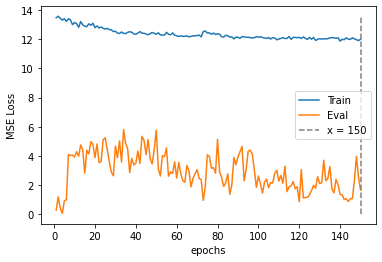

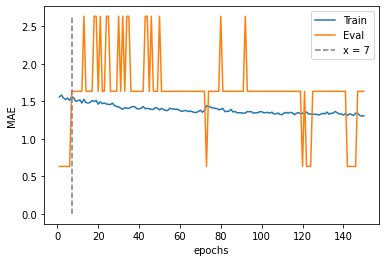

In [75]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [76]:
columns_to_keep

['x',
 'y',
 'dt_placement',
 'day',
 'month',
 'week',
 'year',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'ndvi',
 'ndwi',
 'ndmi',
 'ndbi',
 'ndvi_mean',
 'ndvi_std',
 'ndwi_mean',
 'ndwi_std',
 'ndmi_mean',
 'ndmi_std',
 'ndbi_mean',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'acc_rainfall_jan',
 'mosq_now']

In [77]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14262.127273,NaN,NaN,NaN,14005.407407,NaN,NaN,NaN,1.216681,1.216681,1.216681,1.216681,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14350.503937,NaN,NaN,NaN,14039.913386,NaN,NaN,NaN,0.020066,0.020066,0.020066,0.020066,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14266.670330,NaN,NaN,NaN,14021.142857,NaN,NaN,NaN,0.000223,0.000223,0.000223,0.000223,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14220.556818,NaN,NaN,NaN,13991.261364,NaN,NaN,NaN,0.406945,0.406945,0.406945,0.406945,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14455.555556,NaN,NaN,NaN,14110.933333,NaN,NaN,NaN,1.073789,1.073789,1.073789,1.073789,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.087912,13814.912088,14066.867167,14351.524725,14398.353421,14398.353421,13633.095356,13714.459576,13666.662177,13666.662177,0.000000,0.010527,0.018527,1077.473491,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31,12,2022,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,14220.125000,13826.840909,14059.543512,14303.178977,14298.990836,14298.990836,13628.980230,13709.562500,13664.076979,13664.076979,0.000000,0.428337,0.651870,1158.041206,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31,12,2022,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,14247.533333,13901.000000,14102.108244,14304.360317,14292.009319,14292.009319,13680.272975,13767.332540,13717.169176,13717.169176,0.000000,1.072827,3.092039,1224.182744,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31,12,2022,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,14215.175325,13808.636364,13999.296165,14300.688312,14376.047759,14376.047759,13638.179305,13735.676716,13690.758483,13690.758483,0.000000,-0.000000,0.134849,1089.631358,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981


In [78]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep, mean_lst = True)

In [79]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [80]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [81]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [82]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [83]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

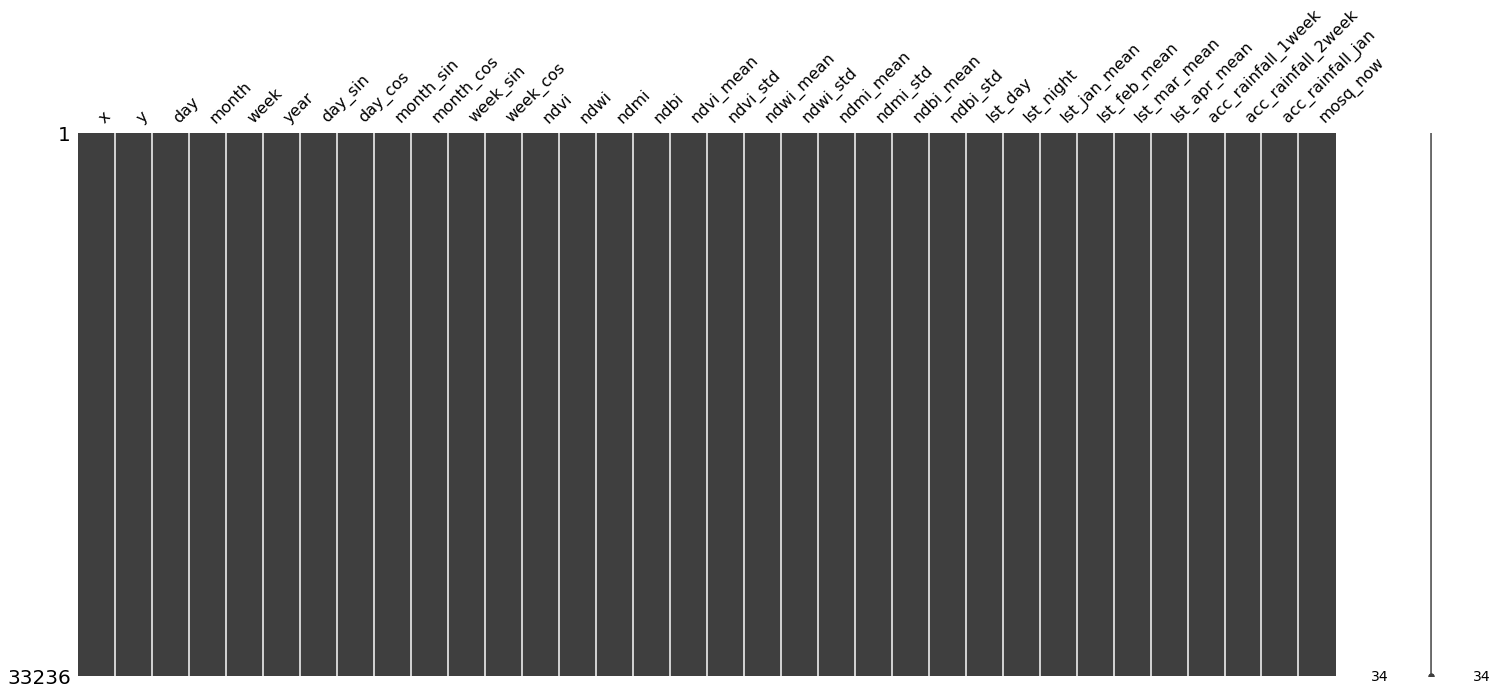

In [84]:
missingno.matrix(dataset_mamoth)

In [85]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [86]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [87]:
predictions = give_predictions(model, dataset_mamoth)

In [88]:
mosqutio_predictions['mosq_pred'] = predictions

In [89]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.215876,40.552658,2010-01-01,57
1,23.139532,40.695359,2010-01-01,123
2,22.758634,41.016242,2010-01-01,96
3,22.109199,40.888821,2010-01-01,29
4,22.441443,40.269748,2010-01-01,87
...,...,...,...,...
33231,22.758634,41.016242,2022-12-31,4
33232,22.109199,40.888821,2022-12-31,6
33233,22.441443,40.269748,2022-12-31,9
33234,23.542098,41.085750,2022-12-31,3


In [90]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', index = False)